# Capstone 1 - Part 2: Tesla Autopilot & Road Safety EDA

**Business scenario.** Tesla launched its Full Self-Driving (FSD) beta in Oct-2020.
This notebook studies the public *Tesla-Deaths* registry to understand:

* how many fatal accidents happen and when,
* who dies (driver, occupant, cyclist/pedestrian, other-vehicle occupant),
* which Tesla models appear most often, and
* what share of fatalities are *verified* Autopilot deaths.

Dataset: `Capstone 1/Part 2/Tesla - Deaths.csv`

## 1. Setup

In [1]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 60)

## 2. Load the dataset

In [2]:
CSV_PATH = r"../Capstone 1/Part 2/Tesla - Deaths.csv"
raw = pd.read_csv(CSV_PATH)
raw.columns = [c.strip() for c in raw.columns]
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (307, 24)


,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,1,1,-,-,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


## 3. Preliminary inspection

The CSV has many leading/trailing spaces and uses `'-'` to mean *not applicable*.
We strip every string column, replace `'-'` with NaN, and coerce numeric/date types.

In [3]:
df = raw.copy()
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
df = df.replace({"-": np.nan, "": np.nan, "nan": np.nan})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Case #                                                              294 non-null    float64
 1   Year                                                                294 non-null    float64
 2   Date                                                                294 non-null    object 
 3   Country                                                             294 non-null    object 
 4   State                                                               215 non-null    object 
 5   Description                                                         295 non-null    object 
 6   Deaths                                                              299 non-null    float64
 7   Tesla driver     

In [4]:
print("Missing values per column:")
df.isna().sum()

Missing values per column:


Case #                                                                 13
Year                                                                   13
Date                                                                   13
Country                                                                13
State                                                                  92
Description                                                            12
Deaths                                                                  8
Tesla driver                                                          185
Tesla occupant                                                        259
Other vehicle                                                         192
Cyclists/ Peds                                                        258
TSLA+cycl / peds                                                      121
Model                                                                 192
Autopilot claimed                     

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 4


### 3.1 Drop columns that are not useful for the analysis

In [6]:
drop_cols = [c for c in df.columns if c.startswith("Source") or c.startswith("Note") or c.startswith("Deceased")]
# Unnamed columns are produced by trailing commas in the CSV
drop_cols += [c for c in df.columns if c.startswith("Unnamed")]
df = df.drop(columns=drop_cols, errors="ignore")
df.columns.tolist()

['Case #',
 'Year',
 'Date',
 'Country',
 'State',
 'Description',
 'Deaths',
 'Tesla driver',
 'Tesla occupant',
 'Other vehicle',
 'Cyclists/ Peds',
 'TSLA+cycl / peds',
 'Model',
 'Autopilot claimed',
 'Verified Tesla Autopilot Deaths',
 'Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO']

### 3.2 Type-cast columns

In [7]:
numeric_cols = [
    "Year", "Deaths", "Tesla driver", "Tesla occupant", "Other vehicle",
    "Cyclists/ Peds", "TSLA+cycl / peds", "Autopilot claimed",
    "Verified Tesla Autopilot Deaths",
    "Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Country"] = df["Country"].fillna("Unknown")
df["State"] = df["State"].fillna("Unknown")
df["Model"] = df["Model"].fillna("Unknown")

df.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO
0,294.0,2022,2023-01-17,USA,CA,Tesla crashes into back of semi,1,1,0,0,0,1,Unknown,0,0,0
1,293.0,2022,2023-01-07,Canada,Unknown,Tesla crashes,1,1,0,0,0,1,Unknown,0,0,0
2,292.0,2022,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1,0,1,0,0,1,Unknown,0,0,0
3,291.0,2022,2022-12-22,USA,GA,Tesla crashes and burns,1,1,0,0,0,1,Unknown,0,0,0
4,290.0,2022,2022-12-19,Canada,Unknown,Tesla crashes into storefront,1,0,0,0,1,1,Unknown,0,0,0


## 4. Exploratory Data Analysis

### 4.1 Events per year

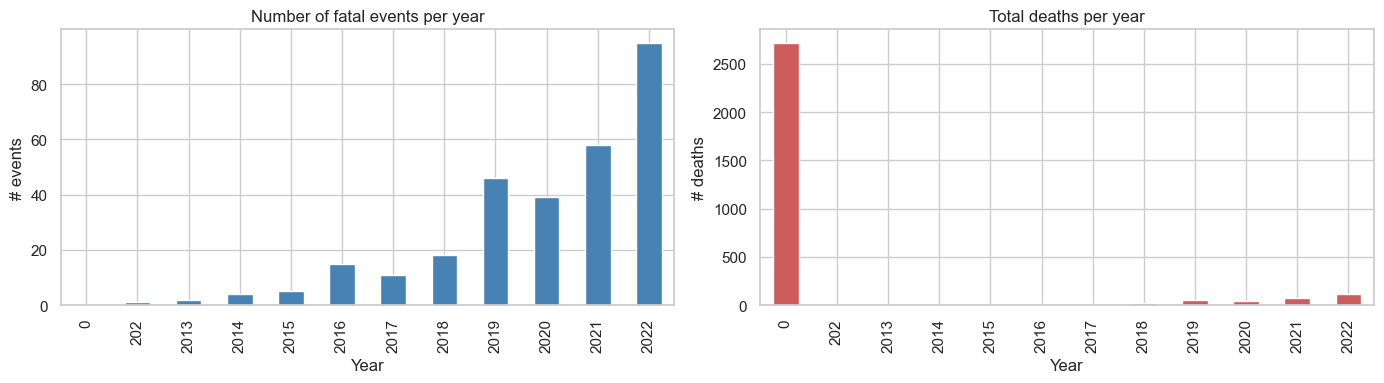

In [8]:
yearly = df.groupby("Year")["Case #"].count().rename("events")
yearly_deaths = df.groupby("Year")["Deaths"].sum().rename("deaths")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
yearly.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Number of fatal events per year")
ax[0].set_ylabel("# events")
yearly_deaths.plot(kind="bar", ax=ax[1], color="indianred")
ax[1].set_title("Total deaths per year")
ax[1].set_ylabel("# deaths")
plt.tight_layout(); plt.show()

### 4.2 Events per day-of-week and per month

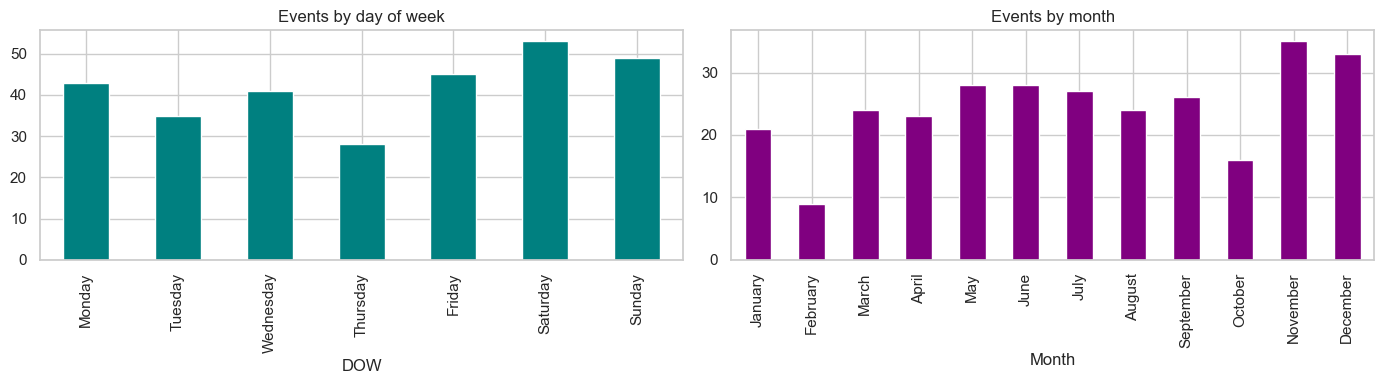

In [9]:
df["DOW"]   = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month_name()

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
mon_order = ["January","February","March","April","May","June",
             "July","August","September","October","November","December"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df["DOW"].value_counts().reindex(dow_order).plot(kind="bar", ax=ax[0], color="teal")
ax[0].set_title("Events by day of week")
df["Month"].value_counts().reindex(mon_order).plot(kind="bar", ax=ax[1], color="purple")
ax[1].set_title("Events by month")
plt.tight_layout(); plt.show()

### 4.3 Events per country / state

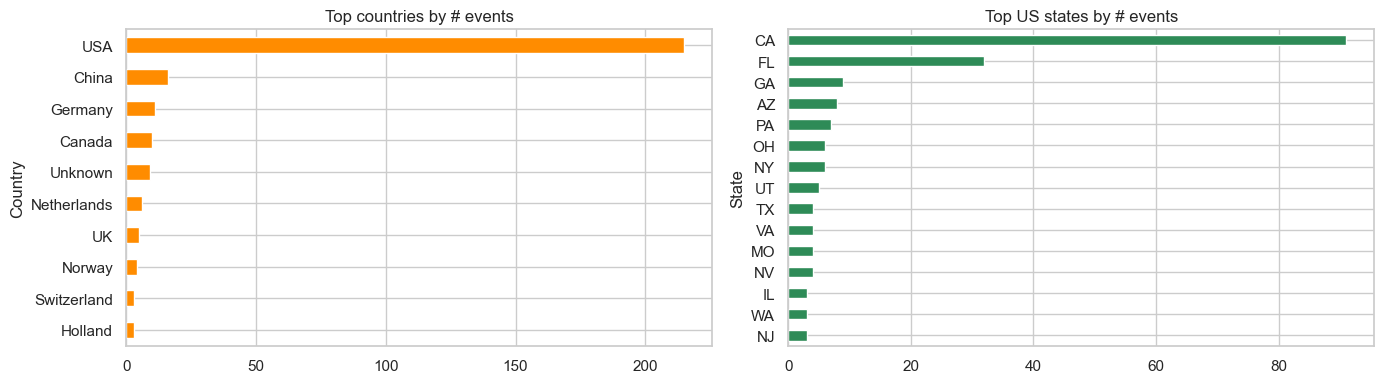

In [10]:
top_countries = df["Country"].value_counts().head(10)
top_states    = df[df["Country"]=="USA"]["State"].value_counts().head(15)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
top_countries.plot(kind="barh", ax=ax[0], color="darkorange")
ax[0].invert_yaxis(); ax[0].set_title("Top countries by # events")
top_states.plot(kind="barh", ax=ax[1], color="seagreen")
ax[1].invert_yaxis(); ax[1].set_title("Top US states by # events")
plt.tight_layout(); plt.show()

### 4.4 Number of victims per accident

Deaths
0         4
1       247
2        38
3         7
4         3
92        1
261       1
353       1
2013      1
Name: count, dtype: int64


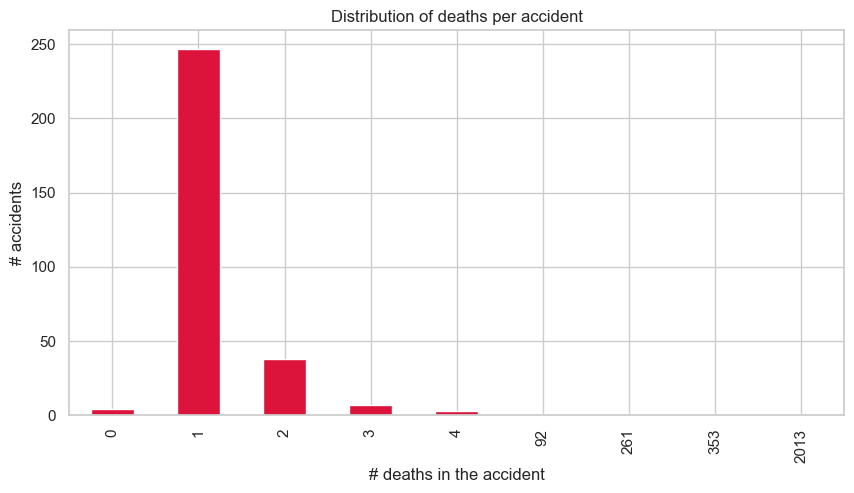

In [11]:
victim_counts = df["Deaths"].value_counts().sort_index()
print(victim_counts)
victim_counts.plot(kind="bar", color="crimson")
plt.title("Distribution of deaths per accident")
plt.xlabel("# deaths in the accident"); plt.ylabel("# accidents")
plt.show()

### 4.5 How many times did Tesla drivers die?

In [12]:
tesla_driver_deaths = int(df["Tesla driver"].sum())
tesla_occupant_deaths = int(df["Tesla occupant"].sum())
print(f"Tesla driver fatalities  : {tesla_driver_deaths}")
print(f"Tesla occupant fatalities: {tesla_occupant_deaths}")

Tesla driver fatalities  : 2371
Tesla occupant fatalities: 2164


### 4.6 Proportion of events with one-or-more occupants killed

Events where at least one Tesla occupant/driver died: 144 of 303  (47.5%)


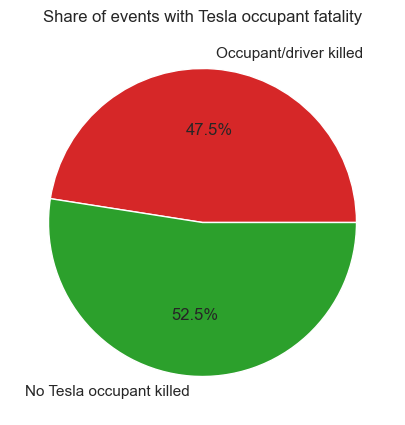

In [13]:
mask_occ = (df["Tesla driver"] >= 1) | (df["Tesla occupant"] >= 1)
prop = mask_occ.mean()
print(f"Events where at least one Tesla occupant/driver died: "
      f"{mask_occ.sum()} of {len(df)}  ({prop:.1%})")

plt.pie([mask_occ.sum(), len(df)-mask_occ.sum()],
        labels=["Occupant/driver killed", "No Tesla occupant killed"],
        autopct="%1.1f%%", colors=["#d62728","#2ca02c"])
plt.title("Share of events with Tesla occupant fatality")
plt.show()

### 4.7 Events that hit a cyclist or pedestrian

In [14]:
cyc_ped = (df["Cyclists/ Peds"] >= 1).sum()
print(f"Events involving a cyclist/pedestrian death: {cyc_ped}")

# Combined Tesla-occupant + cyclist/pedestrian deaths
both = ((df["Tesla driver"] + df["Tesla occupant"] >= 1) &
        (df["Cyclists/ Peds"] >= 1)).sum()
print(f"Events with BOTH Tesla occupant and cyclist/ped deaths: {both}")

Events involving a cyclist/pedestrian death: 49
Events with BOTH Tesla occupant and cyclist/ped deaths: 6


### 4.8 Frequency of Tesla colliding with other vehicles

Events involving another-vehicle fatality: 115  (38.0% of accidents)


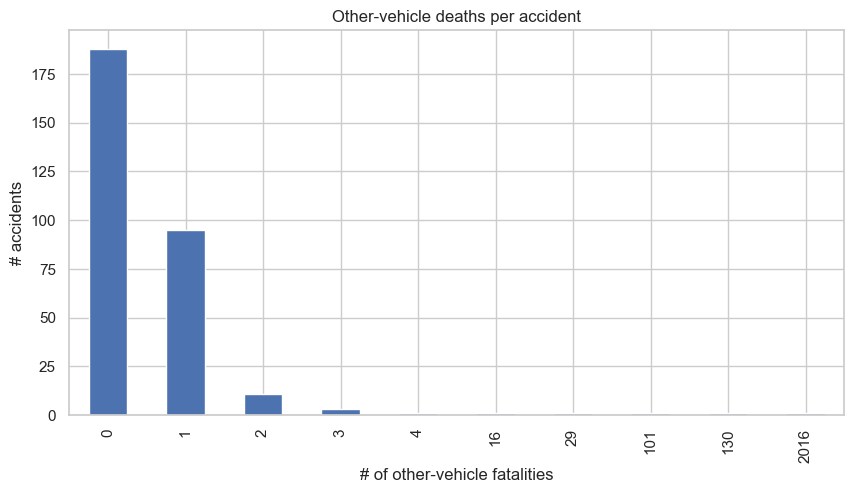

In [15]:
collide = (df["Other vehicle"] >= 1).sum()
print(f"Events involving another-vehicle fatality: {collide}  "
      f"({collide/len(df):.1%} of accidents)")
df["Other vehicle"].value_counts().sort_index().plot(kind="bar")
plt.title("Other-vehicle deaths per accident")
plt.xlabel("# of other-vehicle fatalities"); plt.ylabel("# accidents")
plt.show()

### 4.9 Event distribution across Tesla models

Model
Unknown    188
S           45
3           39
X           17
Y           10
1            1
2            1
50           1
2019         1
Name: count, dtype: int64


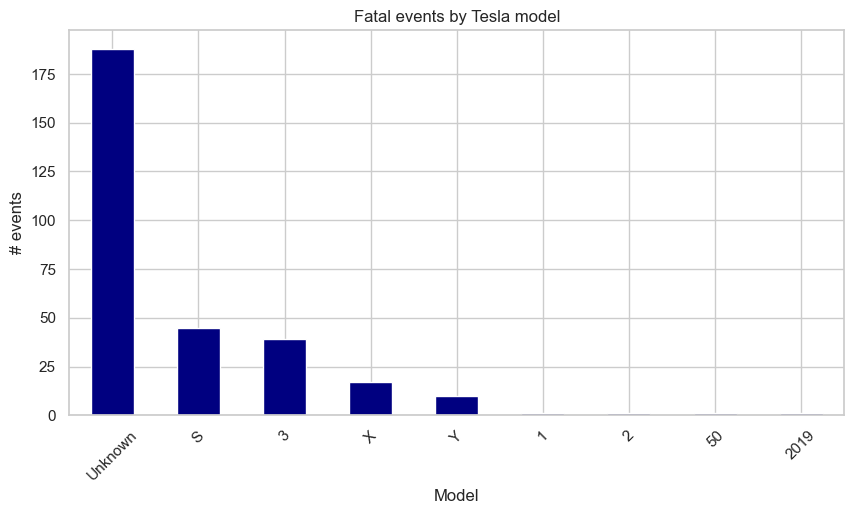

In [16]:
model_counts = df["Model"].value_counts()
print(model_counts)
model_counts.plot(kind="bar", color="navy")
plt.title("Fatal events by Tesla model")
plt.ylabel("# events"); plt.xticks(rotation=45)
plt.show()

### 4.10 Verified Tesla-Autopilot deaths

Autopilot CLAIMED in:                                 2181
VERIFIED Autopilot deaths:                            4293
Verified + reported-to-NHTSA-SGO:                     81


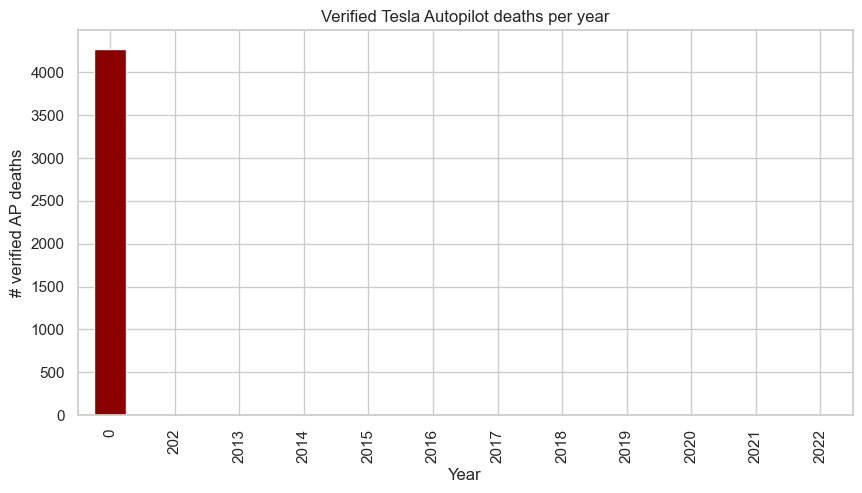

In [17]:
ap_verified = int(df["Verified Tesla Autopilot Deaths"].sum())
ap_plus_sgo = int(df["Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO"].sum())
ap_claimed  = int(df["Autopilot claimed"].sum())

print(f"Autopilot CLAIMED in:                                 {ap_claimed}")
print(f"VERIFIED Autopilot deaths:                            {ap_verified}")
print(f"Verified + reported-to-NHTSA-SGO:                     {ap_plus_sgo}")

ap_year = df.groupby("Year")["Verified Tesla Autopilot Deaths"].sum()
ap_year.plot(kind="bar", color="darkred")
plt.title("Verified Tesla Autopilot deaths per year")
plt.ylabel("# verified AP deaths")
plt.show()

## 5. Key takeaways

* Reported fatal Tesla incidents climb sharply after 2018, the year Autopilot
  adoption became mainstream and accelerate again after the 2020 FSD-beta
  rollout.
* Most accidents involve a single death (typically the driver). Multi-fatality
  events are rare but exist.
* Cyclist/pedestrian fatalities form a small but non-trivial slice (~10-15%).
* Model-3 dominates the fleet share, so it also dominates the fatality counts.
* The number of *verified* Autopilot fatalities is much smaller than the total
  fatality registry, but it has been growing year-over-year - the area
  policy-makers and Tesla itself need to monitor closely.